In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import holidays
import numpy as np


# Análise Global

In [2]:
data = pd.read_csv('dados/training_data.csv', encoding="latin1")

In [3]:
data.head()

,city_name,record_date,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,AVERAGE_CLOUDINESS,AVERAGE_PRECIPITATION,AVERAGE_RAIN
0,Porto,2019-08-29 07:00:00,Medium,41.5,11.5,71.4,LIGHT,15.0,1019.0,100.0,3.0,NaN,0.0,NaN
1,Porto,2018-08-10 14:00:00,High,41.7,48.3,87.4,LIGHT,21.0,1021.0,53.0,5.0,céu claro,0.0,NaN
2,Porto,2019-09-01 16:00:00,High,38.6,38.4,85.2,LIGHT,26.0,1014.0,61.0,4.0,NaN,0.0,NaN
3,Porto,2019-02-26 11:00:00,High,37.4,61.0,94.1,LIGHT,18.0,1025.0,48.0,4.0,céu claro,0.0,NaN
4,Porto,2019-06-06 12:00:00,Medium,41.6,50.4,77.0,LIGHT,15.0,1008.0,82.0,10.0,NaN,0.0,NaN


In [4]:
data.tail()

,city_name,record_date,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,AVERAGE_CLOUDINESS,AVERAGE_PRECIPITATION,AVERAGE_RAIN
6807,Porto,2019-02-23 09:00:00,Low,41.2,3.7,86.9,LIGHT,9.0,1030.0,71.0,4.0,céu claro,0.0,NaN
6808,Porto,2019-06-08 18:00:00,Medium,38.9,51.9,76.9,LIGHT,17.0,1020.0,63.0,6.0,NaN,0.0,NaN
6809,Porto,2018-10-02 04:00:00,NaN,39.6,0.0,89.1,DARK,15.0,1020.0,39.0,4.0,céu claro,0.0,NaN
6810,Porto,2019-01-30 01:00:00,NaN,41.6,0.0,85.5,DARK,8.0,1018.0,81.0,1.0,algumas nuvens,0.0,NaN
6811,Porto,2019-06-15 21:00:00,Medium,41.7,32.9,78.1,DARK,15.0,1021.0,72.0,4.0,NaN,0.0,NaN


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city_name                6812 non-null   object 
 1   record_date              6812 non-null   object 
 2   AVERAGE_SPEED_DIFF       4612 non-null   object 
 3   AVERAGE_FREE_FLOW_SPEED  6812 non-null   float64
 4   AVERAGE_TIME_DIFF        6812 non-null   float64
 5   AVERAGE_FREE_FLOW_TIME   6812 non-null   float64
 6   LUMINOSITY               6812 non-null   object 
 7   AVERAGE_TEMPERATURE      6812 non-null   float64
 8   AVERAGE_ATMOSP_PRESSURE  6812 non-null   float64
 9   AVERAGE_HUMIDITY         6812 non-null   float64
 10  AVERAGE_WIND_SPEED       6812 non-null   float64
 11  AVERAGE_CLOUDINESS       4130 non-null   object 
 12  AVERAGE_PRECIPITATION    6812 non-null   float64
 13  AVERAGE_RAIN             563 non-null    object 
dtypes: float64(8), object(6)

In [6]:
data.isna().sum()

city_name                     0
record_date                   0
AVERAGE_SPEED_DIFF         2200
AVERAGE_FREE_FLOW_SPEED       0
AVERAGE_TIME_DIFF             0
AVERAGE_FREE_FLOW_TIME        0
LUMINOSITY                    0
AVERAGE_TEMPERATURE           0
AVERAGE_ATMOSP_PRESSURE       0
AVERAGE_HUMIDITY              0
AVERAGE_WIND_SPEED            0
AVERAGE_CLOUDINESS         2682
AVERAGE_PRECIPITATION         0
AVERAGE_RAIN               6249
dtype: int64

In [7]:
data.drop(['city_name', 'AVERAGE_RAIN', 'AVERAGE_PRECIPITATION'], axis=1, inplace=True)

In [8]:
data["record_date"] = pd.to_datetime(data["record_date"])

In [9]:
data["year"] = data["record_date"].dt.year
data["month"] = data["record_date"].dt.month
data["day"] = data["record_date"].dt.day
data["hour"] = data["record_date"].dt.hour
data["weekday"] = data["record_date"].dt.dayofweek  # 0=monday, 6=sunday
data["is_weekend"] = (data["weekday"] >= 5).astype(int)

pt_holidays = holidays.Portugal()
data["is_holiday"] = data["record_date"].dt.date.isin(pt_holidays).astype(int)

def season(month, day):
    if (month == 12 and day >= 21) or (month <= 3 and day < 20) or (month in [1,2]):
        return "Winter"
    elif (month == 3 and day >= 20) or (month in [4,5]) or (month == 6 and day < 21):
        return "Spring"
    elif (month == 6 and day >= 21) or (month in [7,8]) or (month == 9 and day < 23):
        return "Summer"
    else:
        return "Autumn"

data["season"] = data.apply(lambda x: season(x["month"], x["day"]), axis=1)

In [10]:
data["AVERAGE_SPEED_DIFF"].value_counts()

AVERAGE_SPEED_DIFF
Medium       1651
Low          1419
High         1063
Very_High     479
Name: count, dtype: int64

In [11]:
data["AVERAGE_SPEED_DIFF_N"] = data["AVERAGE_SPEED_DIFF"].fillna("D")

map_dict = {
    "Low": 1,
    "Medium": 2,
    "High": 3,
    "Very_High": 4,
    "D": 0
}

data["AVERAGE_SPEED_DIFF_N"] = (
    data["AVERAGE_SPEED_DIFF"]
    .fillna("D")        # substitui NaN
    .map(map_dict)      # mapeia Low/Medium/High/...
)   

In [12]:
data.isna().sum()

record_date                   0
AVERAGE_SPEED_DIFF         2200
AVERAGE_FREE_FLOW_SPEED       0
AVERAGE_TIME_DIFF             0
AVERAGE_FREE_FLOW_TIME        0
LUMINOSITY                    0
AVERAGE_TEMPERATURE           0
AVERAGE_ATMOSP_PRESSURE       0
AVERAGE_HUMIDITY              0
AVERAGE_WIND_SPEED            0
AVERAGE_CLOUDINESS         2682
year                          0
month                         0
day                           0
hour                          0
weekday                       0
is_weekend                    0
is_holiday                    0
season                        0
AVERAGE_SPEED_DIFF_N          0
dtype: int64

In [13]:
data["LUMINOSITY"].value_counts()

LUMINOSITY
LIGHT        3293
DARK         3253
LOW_LIGHT     266
Name: count, dtype: int64

In [14]:
map_dict = {
    "DARK": 0,
    "LOW_LIGHT": 1,
    "LIGHT": 2
}

data["LUMINOSITY_N"] = data["LUMINOSITY"].map(map_dict)

In [15]:
data["AVERAGE_CLOUDINESS"].value_counts()

AVERAGE_CLOUDINESS
céu claro            1582
céu pouco nublado     516
nuvens dispersas      459
nuvens quebrados      448
algumas nuvens        422
nuvens quebradas      416
céu limpo             153
tempo nublado          67
nublado                67
Name: count, dtype: int64

In [16]:
map_cloudiness = {
    "céu limpo": 0,
    "céu claro": 1,
    "céu pouco nublado": 2,
    "algumas nuvens": 3,
    "nuvens dispersas": 4,
    "nuvens quebradas": 5,
    "nuvens quebrados": 5,
    "tempo nublado": 6,
    "nublado": 7
}

data["AVERAGE_CLOUDINESS_N"] = data["AVERAGE_CLOUDINESS"].map(map_cloudiness)


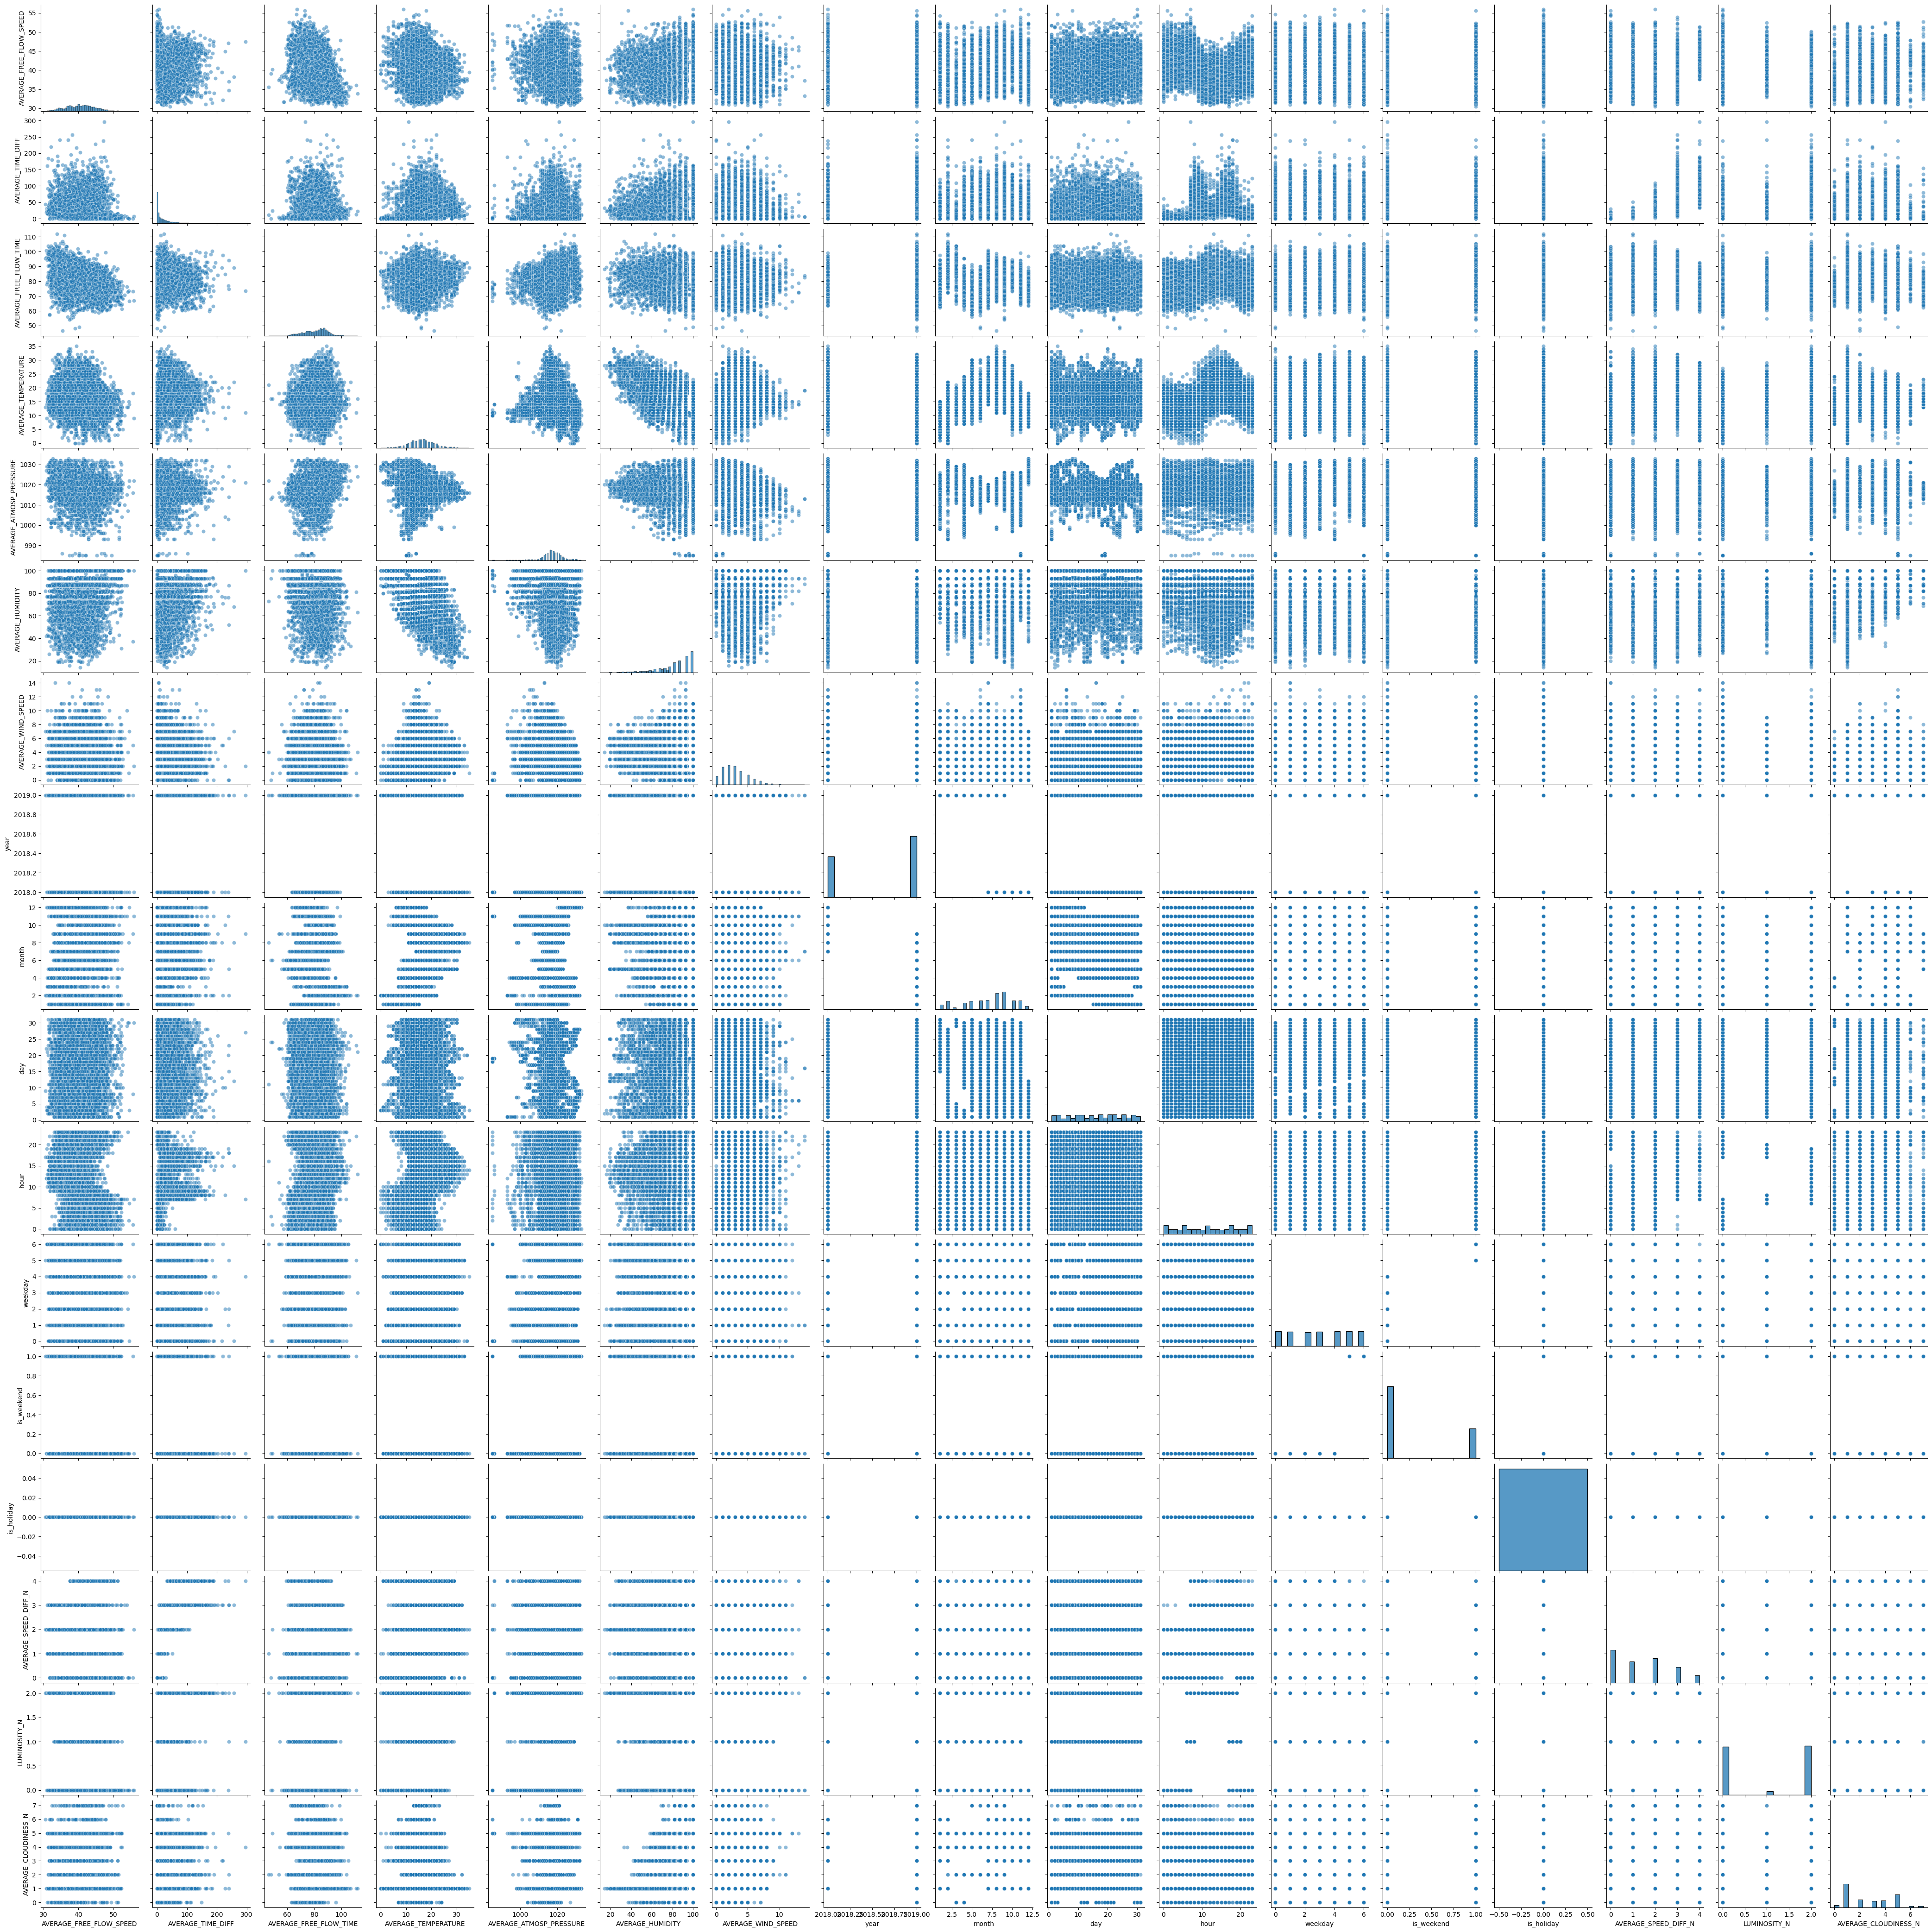

In [17]:
sns.pairplot(data, diag_kind="hist", plot_kws={"alpha": 0.5})
plt.show()


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   record_date              6812 non-null   datetime64[ns]
 1   AVERAGE_SPEED_DIFF       4612 non-null   object        
 2   AVERAGE_FREE_FLOW_SPEED  6812 non-null   float64       
 3   AVERAGE_TIME_DIFF        6812 non-null   float64       
 4   AVERAGE_FREE_FLOW_TIME   6812 non-null   float64       
 5   LUMINOSITY               6812 non-null   object        
 6   AVERAGE_TEMPERATURE      6812 non-null   float64       
 7   AVERAGE_ATMOSP_PRESSURE  6812 non-null   float64       
 8   AVERAGE_HUMIDITY         6812 non-null   float64       
 9   AVERAGE_WIND_SPEED       6812 non-null   float64       
 10  AVERAGE_CLOUDINESS       4130 non-null   object        
 11  year                     6812 non-null   int32         
 12  month                    6812 non-

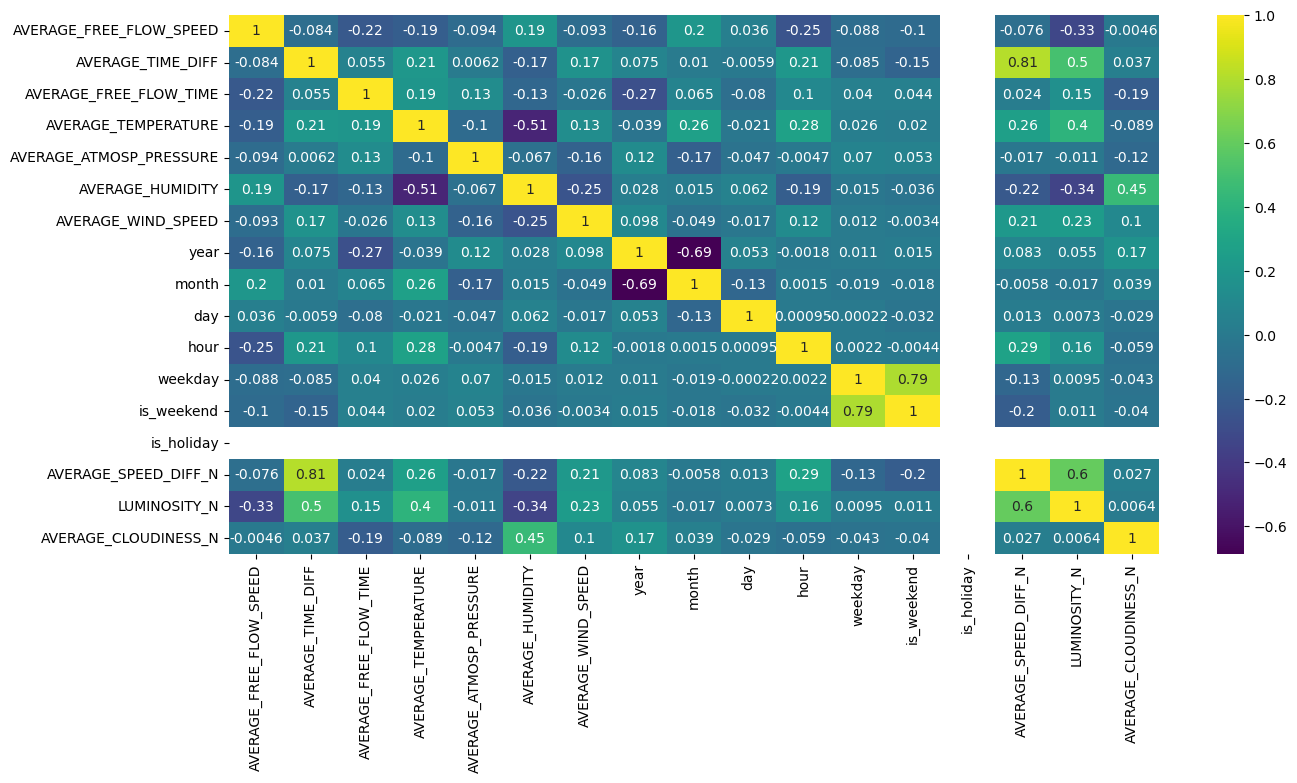

In [19]:
numeric_data = data.select_dtypes(include='number')
plt.figure(figsize=(15, 7))
sns.heatmap(numeric_data.corr(), annot=True, cmap="viridis")
plt.show()

Text(0.5, 1.0, 'Matriz de Correlação - Variáveis de Tráfego')

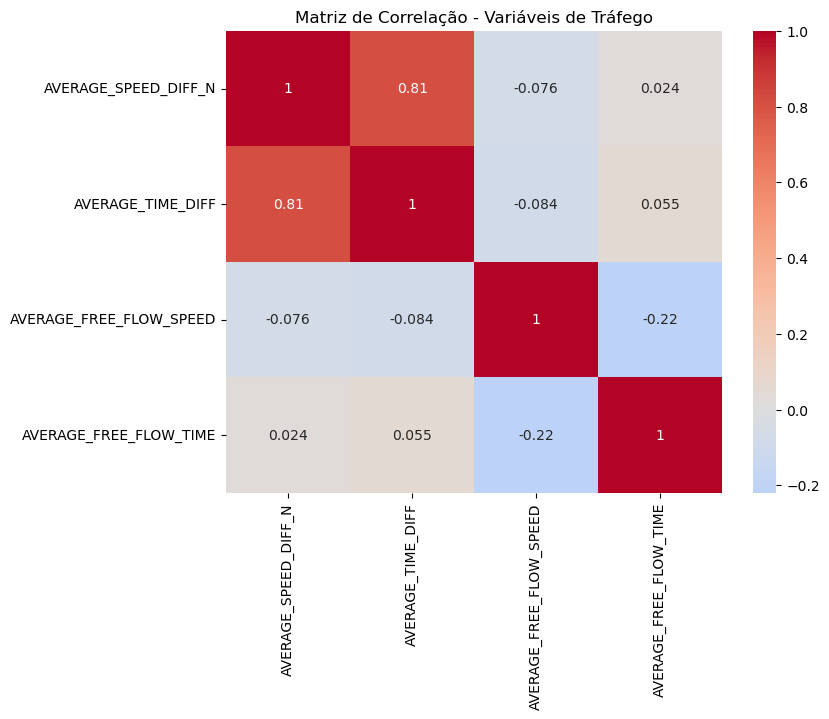

In [20]:
traffic_vars = ['AVERAGE_SPEED_DIFF_N', 'AVERAGE_TIME_DIFF', 'AVERAGE_FREE_FLOW_SPEED',
                'AVERAGE_FREE_FLOW_TIME']
corr_matrix = data[traffic_vars].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação - Variáveis de Tráfego')

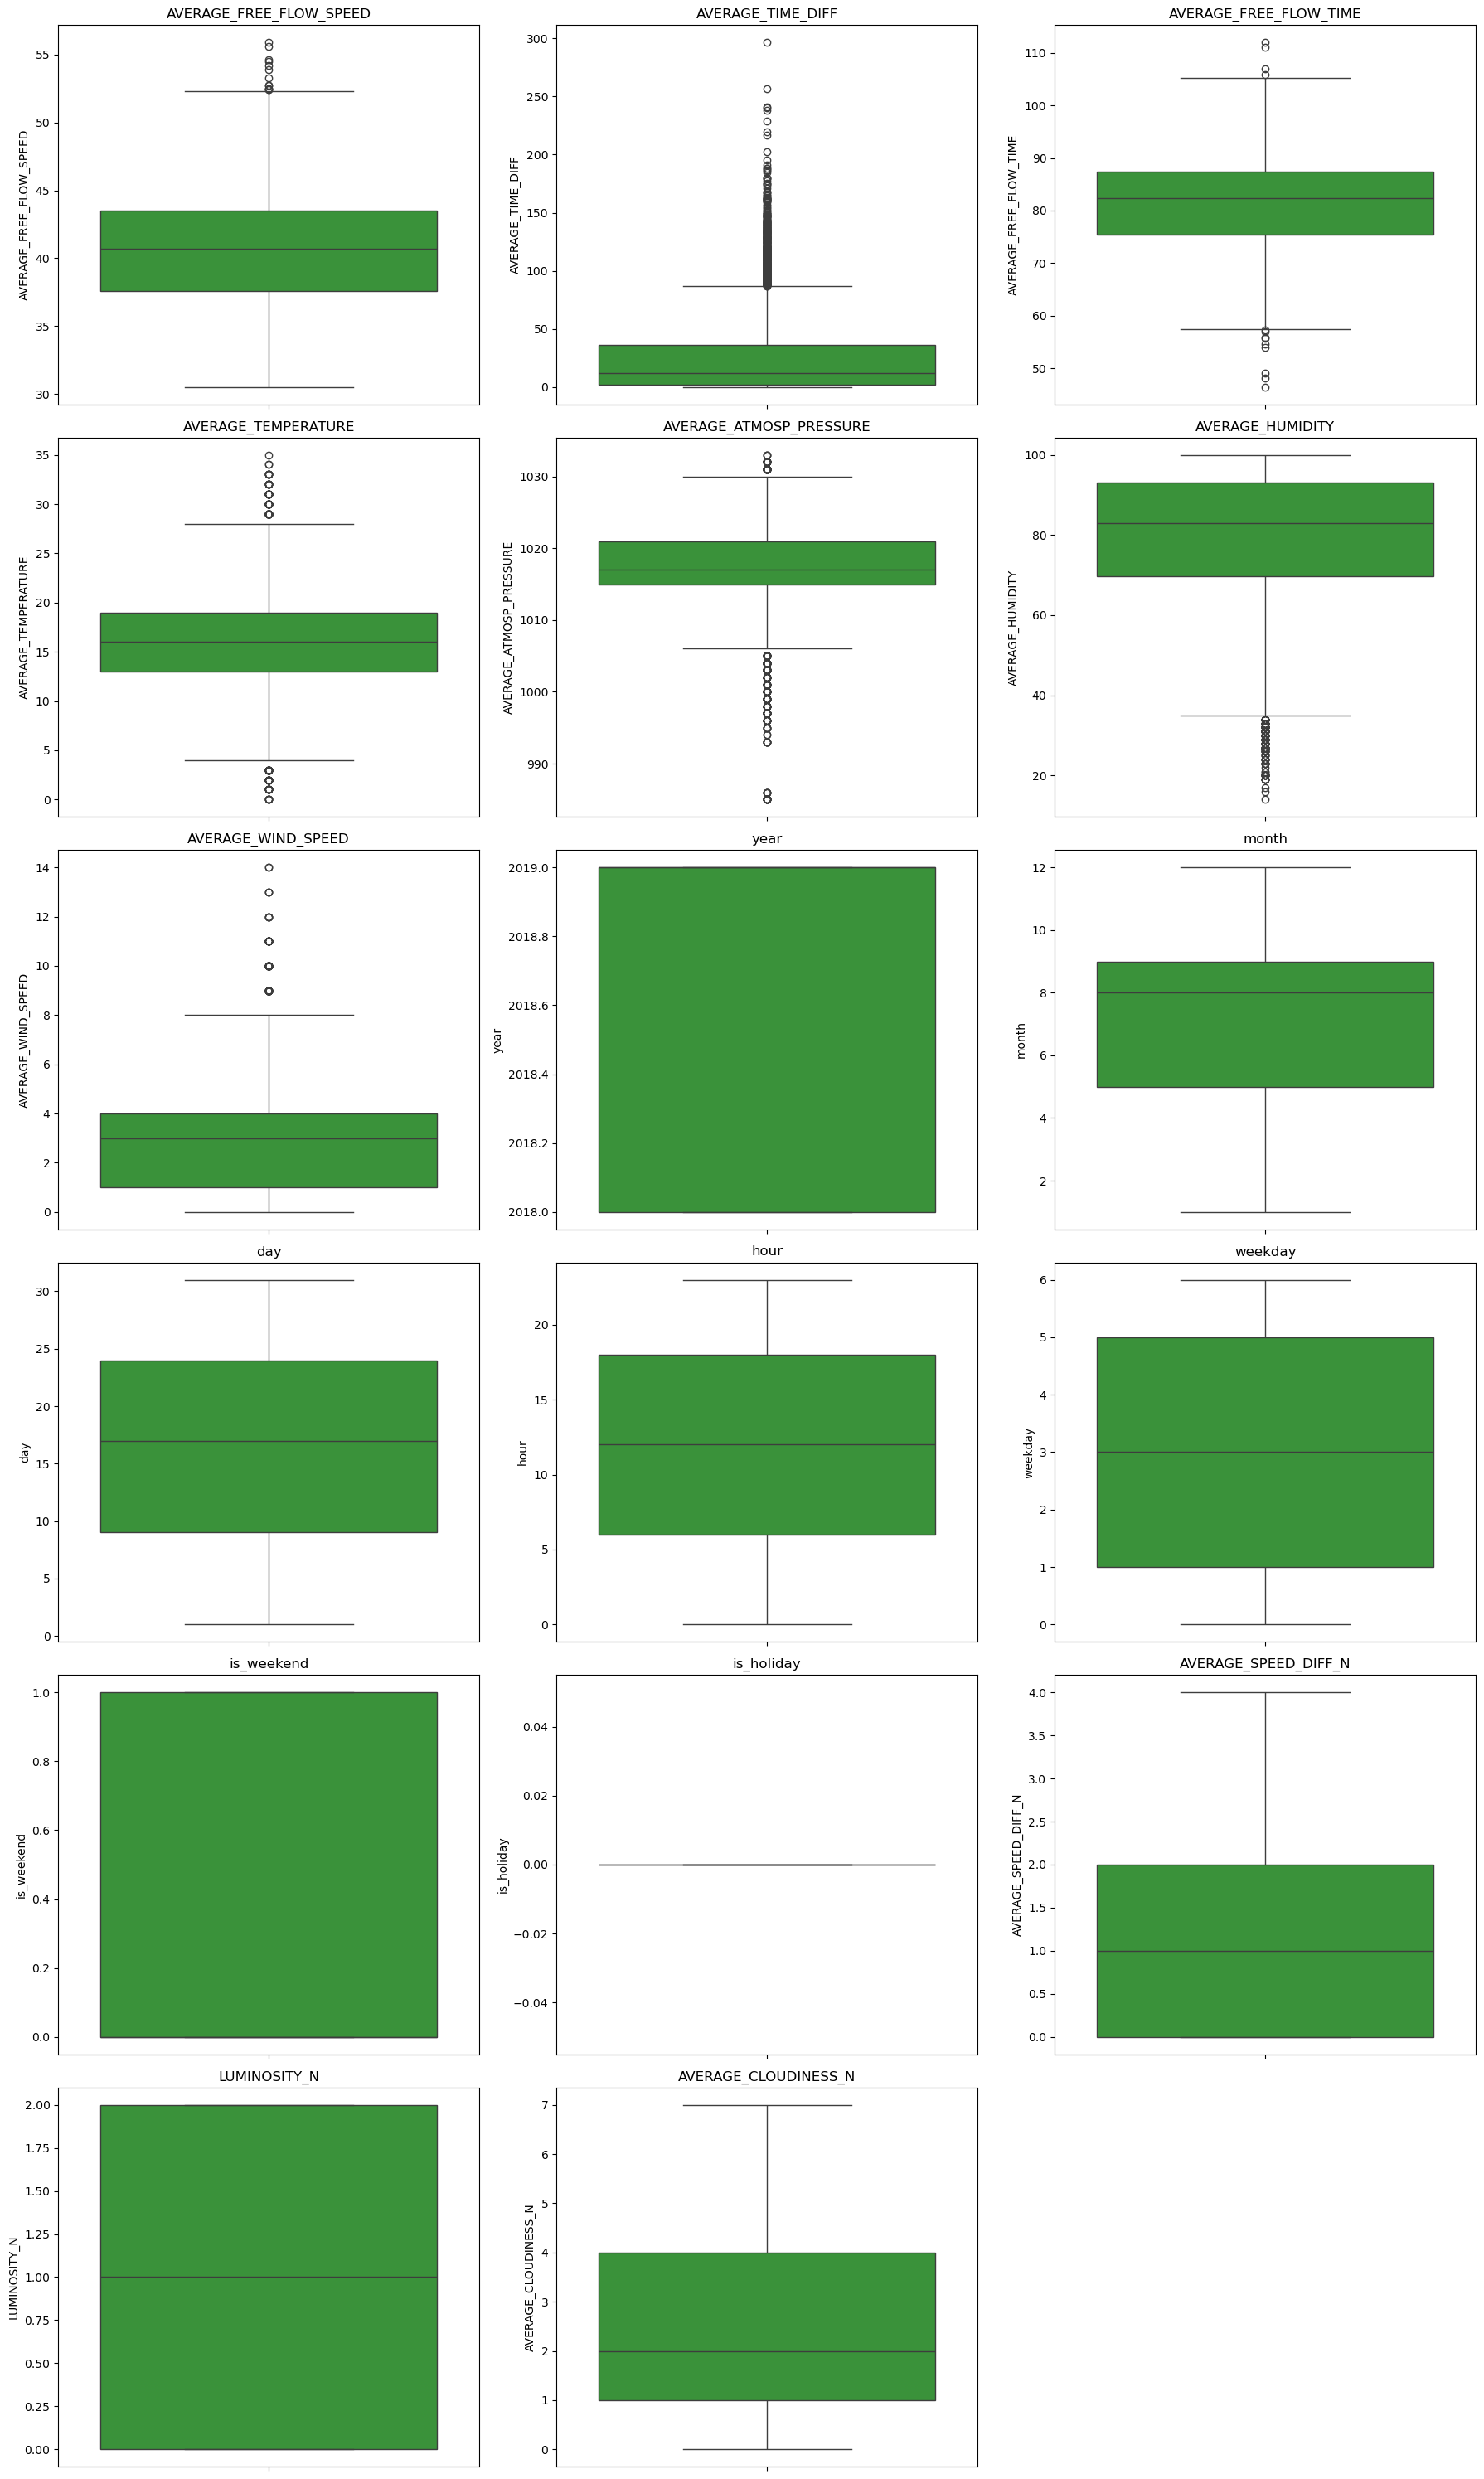

In [21]:
n_cols = len(numeric_data.columns)
n_rows = (n_cols // 3) + 1  

plt.figure(figsize=(18, n_rows * 5))

for i, col in enumerate(numeric_data.columns):
    plt.subplot(n_rows, 3, i+1)
    sns.boxplot(y=numeric_data[col], color="#2ca02c")  
    plt.title(col)

plt.tight_layout()
plt.show()

# Análise Temporal

C:\Users\emman\AppData\Local\Temp\ipykernel_25380\3611137744.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="AVERAGE_SPEED_DIFF", y="AVERAGE_TIME_DIFF", data=data, palette="Greens")


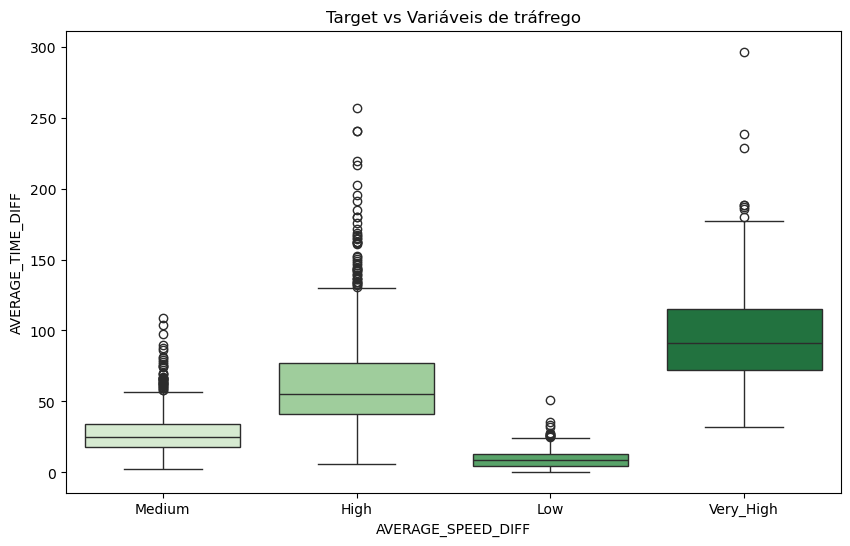

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(x="AVERAGE_SPEED_DIFF", y="AVERAGE_TIME_DIFF", data=data, palette="Greens")
plt.xlabel("AVERAGE_SPEED_DIFF")
plt.ylabel("AVERAGE_TIME_DIFF")
plt.title("Target vs Variáveis de tráfrego")
plt.show()

In [23]:
hourly_avg = data.groupby('hour')['AVERAGE_TIME_DIFF'].mean()
hourly_avg

hour
0      4.005036
1      3.337631
2      3.076923
3      3.070847
4      2.575000
5      2.529818
6      3.683391
7     29.330389
8     55.523183
9     50.641489
10    41.290000
11    34.797070
12    25.192908
13    20.321053
14    35.218085
15    52.309643
16    57.979359
17    64.031690
18    61.282927
19    32.989789
20    12.203716
21     8.497193
22     6.877076
23     5.873913
Name: AVERAGE_TIME_DIFF, dtype: float64

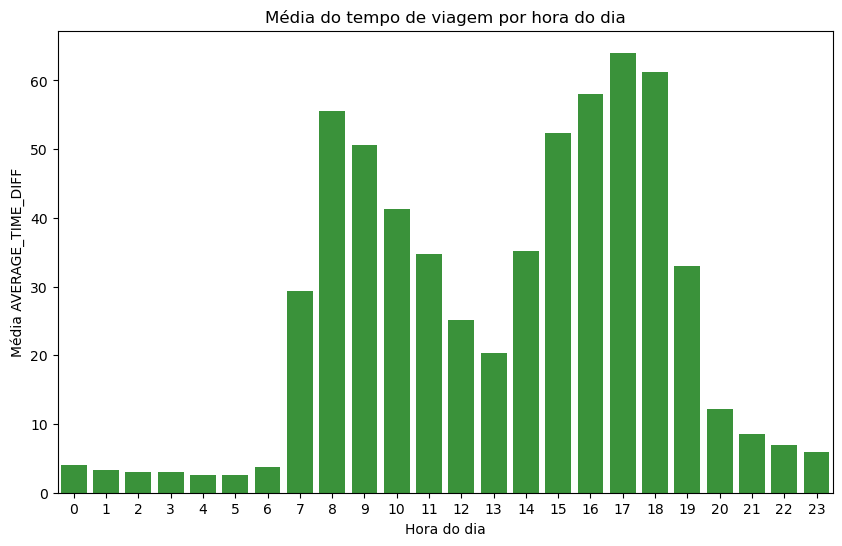

In [24]:
plt.figure(figsize=(10,6))
sns.barplot(x=hourly_avg.index, y=hourly_avg.values, color="#2ca02c")
plt.xlabel("Hora do dia")
plt.ylabel("Média AVERAGE_TIME_DIFF")
plt.title("Média do tempo de viagem por hora do dia")
plt.show()

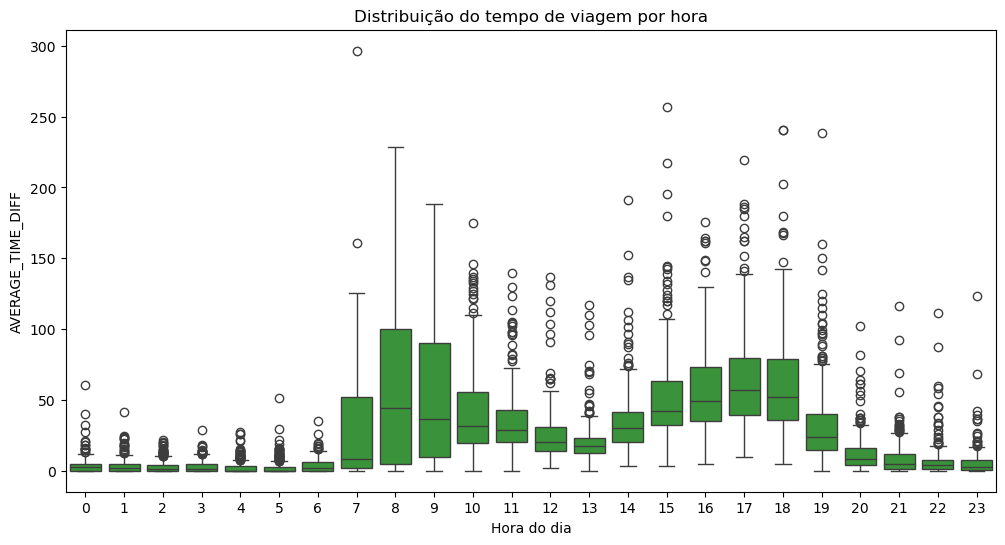

In [25]:
plt.figure(figsize=(12,6))
sns.boxplot(x='hour', y='AVERAGE_TIME_DIFF', data=data, color="#2ca02c")
plt.xlabel("Hora do dia")
plt.ylabel("AVERAGE_TIME_DIFF")
plt.title("Distribuição do tempo de viagem por hora")
plt.show()

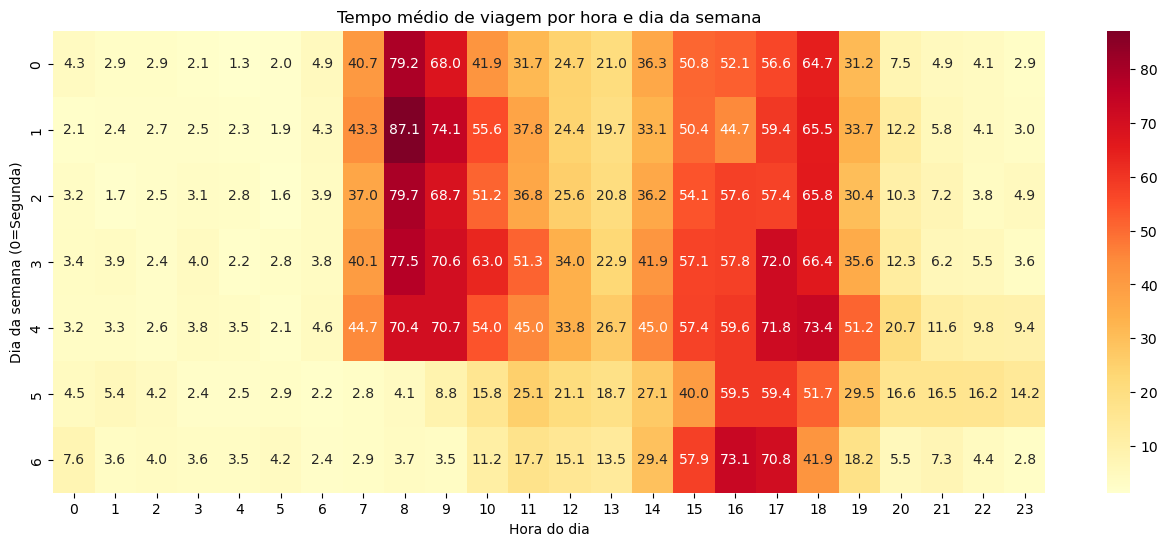

In [26]:
pivot = data.pivot_table(index='weekday', columns='hour', values='AVERAGE_TIME_DIFF', aggfunc='mean')

plt.figure(figsize=(16,6))
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt=".1f")
plt.xlabel("Hora do dia")
plt.ylabel("Dia da semana (0=Segunda)")
plt.title("Tempo médio de viagem por hora e dia da semana")
plt.show()


In [27]:


#Definir como horário de pico as horas com média acima da mediana
threshold = hourly_avg.median()
peak_hours = hourly_avg[hourly_avg > threshold].index.tolist()
data['is_peak_hour'] = data['hour'].apply(lambda x: 1 if x in peak_hours else 0)
data[['hour', 'AVERAGE_TIME_DIFF', 'is_peak_hour']].head(10)


,hour,AVERAGE_TIME_DIFF,is_peak_hour
0,7,11.5,1
1,14,48.3,1
2,16,38.4,1
3,11,61.0,1
4,12,50.4,1
5,7,5.6,1
6,21,4.0,0
7,19,11.8,1
8,12,10.6,1
9,9,10.1,1


In [28]:
data['is_peak_hour'].value_counts()

is_peak_hour
0    3425
1    3387
Name: count, dtype: int64

C:\Users\emman\AppData\Local\Temp\ipykernel_25380\1233343798.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="season", y="AVERAGE_TIME_DIFF", data=data, palette="Pastel1")


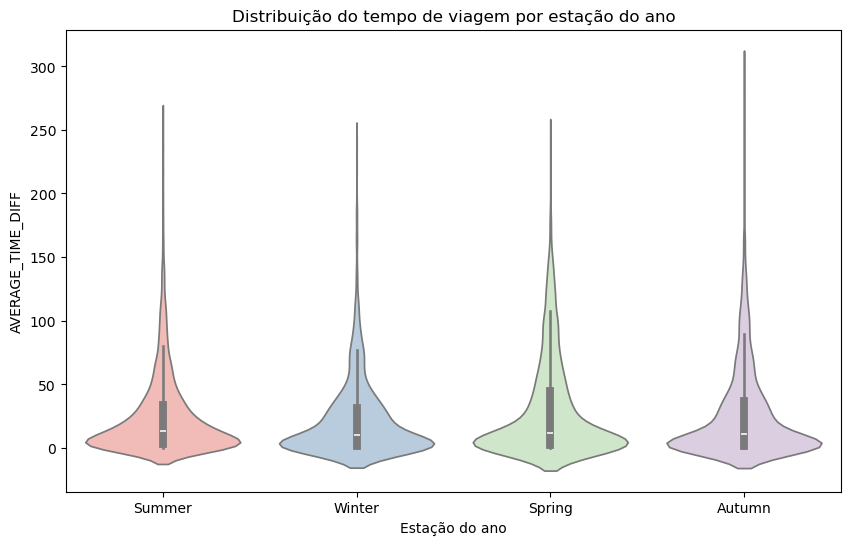

In [29]:
plt.figure(figsize=(10,6))
sns.violinplot(x="season", y="AVERAGE_TIME_DIFF", data=data, palette="Pastel1")
plt.title("Distribuição do tempo de viagem por estação do ano")
plt.xlabel("Estação do ano")
plt.ylabel("AVERAGE_TIME_DIFF")
plt.show()

# Feature Engenieer

- Algumas variáveis já foram criadas na análise para explorar... Faça RUN dessas células acima

In [30]:
data.head(4)

,record_date,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,...,day,hour,weekday,is_weekend,is_holiday,season,AVERAGE_SPEED_DIFF_N,LUMINOSITY_N,AVERAGE_CLOUDINESS_N,is_peak_hour
0,2019-08-29 07:00:00,Medium,41.5,11.5,71.4,LIGHT,15.0,1019.0,100.0,3.0,...,29,7,3,0,0,Summer,2,2,NaN,1
1,2018-08-10 14:00:00,High,41.7,48.3,87.4,LIGHT,21.0,1021.0,53.0,5.0,...,10,14,4,0,0,Summer,3,2,1.0,1
2,2019-09-01 16:00:00,High,38.6,38.4,85.2,LIGHT,26.0,1014.0,61.0,4.0,...,1,16,6,1,0,Summer,3,2,NaN,1
3,2019-02-26 11:00:00,High,37.4,61.0,94.1,LIGHT,18.0,1025.0,48.0,4.0,...,26,11,1,0,0,Winter,3,2,1.0,1


In [31]:
data['poor_visibility'] = ((data['LUMINOSITY_N'] < 2) | (data['AVERAGE_CLOUDINESS_N'] > 3)).astype(int)

In [32]:
data['hour_weekday'] = data['hour'] + data['weekday']*24


In [33]:
data['time_ratio'] = data['AVERAGE_TIME_DIFF'] / data['AVERAGE_FREE_FLOW_TIME']


In [ ]:
def create_time_features(df):
    df = df.sort_values('record_date').copy()
    
    # 1. Lags: O valor da velocidade/tempo nos 15, 30 e 60 min anteriores
    # Assumindo que seus dados são de 15 em 15 min. Se forem diferentes, ajuste o 'periods'
    for col in ['AVERAGE_FREE_FLOW_SPEED', 'AVERAGE_TIME_DIFF']:
        df[f'{col}_lag1'] = df[col].shift(1)
        df[f'{col}_lag2'] = df[col].shift(2)
        df[f'{col}_lag4'] = df[col].shift(4)
    
    # 2. Médias Móveis (Rolling): Para capturar a tendência da última hora
    df['rolling_speed_mean_3h'] = df['AVERAGE_FREE_FLOW_SPEED'].rolling(window=3).mean()
    df['rolling_speed_std_3h'] = df['AVERAGE_FREE_FLOW_SPEED'].rolling(window=3).std()
    
    df['speed_change'] = df['AVERAGE_FREE_FLOW_SPEED'] - df['AVERAGE_FREE_FLOW_SPEED'].shift(1)
    

    df['hour_day_cat'] = df['hour'].astype(str) + '_' + df['weekday'].astype(str)
    
    return df.fillna(method='bfill') # Preenche os NaNs criados pelo shift

data = create_time_features(data)

C:\Users\emman\AppData\Local\Temp\ipykernel_25380\2663456020.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  return df.fillna(method='bfill') # Preenche os NaNs criados pelo shift


In [38]:
data.columns

Index(['record_date', 'AVERAGE_SPEED_DIFF', 'AVERAGE_FREE_FLOW_SPEED',
       'AVERAGE_TIME_DIFF', 'AVERAGE_FREE_FLOW_TIME', 'LUMINOSITY',
       'AVERAGE_TEMPERATURE', 'AVERAGE_ATMOSP_PRESSURE', 'AVERAGE_HUMIDITY',
       'AVERAGE_WIND_SPEED', 'AVERAGE_CLOUDINESS', 'year', 'month', 'day',
       'hour', 'weekday', 'is_weekend', 'is_holiday', 'season',
       'AVERAGE_SPEED_DIFF_N', 'LUMINOSITY_N', 'AVERAGE_CLOUDINESS_N',
       'is_peak_hour', 'poor_visibility', 'hour_weekday', 'time_ratio',
       'AVERAGE_FREE_FLOW_SPEED_lag1', 'AVERAGE_FREE_FLOW_SPEED_lag2',
       'AVERAGE_FREE_FLOW_SPEED_lag4', 'AVERAGE_TIME_DIFF_lag1',
       'AVERAGE_TIME_DIFF_lag2', 'AVERAGE_TIME_DIFF_lag4',
       'rolling_speed_mean_3h', 'rolling_speed_std_3h', 'speed_change',
       'hour_day_cat'],
      dtype='object')

In [39]:
data['hour_sin'] = np.sin(2 * np.pi * data['hour']/24.0)
data['hour_cos'] = np.cos(2 * np.pi * data['hour']/24.0)

In [40]:
data.to_csv('pos_analyse.csv')